In [12]:
# ==============================================================================
# 模块一：环境准备与数据加载 (适配新数据格式版)
# ==============================================================================
import pandas as pd
import numpy as np
import lightgbm as lgb
import optuna
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from chinese_calendar import is_workday, is_holiday
from functools import partial
import json
import matplotlib.pyplot as plt
import seaborn as sns

# -- 配置绘图风格和中文显示 --
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = ['SimHei']  
plt.rcParams['axes.unicode_minus'] = False  

# --- 1. 定义文件路径 ---
# 请确保文件名与上一步生成的保持一致
panel_data_path = r"E:\A智网\电量预测数据\lightgbm模型\133个行业电量天气对齐数据_1.26.csv"
full_weather_path = r"E:\A智网\电量预测数据\lightgbm模型\湖北省每日温度特征_1.26.xlsx"

# --- 2. 加载【历史】电量与天气面板数据 ---
try:
    print("--- 正在加载历史电量与天气面板数据 ---")
    # 【修改】上一步保存用的是 utf_8_sig，这里读取建议用 utf-8，如果报错再尝试 gbk
    try:
        df_main = pd.read_csv(panel_data_path, parse_dates=['date'], encoding='utf-8')
    except UnicodeDecodeError:
        df_main = pd.read_csv(panel_data_path, parse_dates=['date'], encoding='gbk')
        
    print("历史面板数据加载成功！")
    print("数据预览：")
    print(df_main.head())
except Exception as e:
    print(f"加载面板数据时出错: {e}")
    df_main = pd.DataFrame()

# --- 3. 加载并准备【完整天气】数据源 ---
try:
    print("\n--- 正在加载完整天气数据源 ---")
    df_weather_raw = pd.read_excel(full_weather_path)
    
        
    # 1. 寻找日期列
    date_col = None
    for col in df_weather_raw.columns:
        if '日期' in str(col) or 'date' in str(col).lower() or 'DATE' in str(col):
            date_col = col
            break
    
    # 如果找不到，尝试使用索引或者第一列
    if date_col is None:
        date_col = df_weather_raw.columns[0]
    
    # 2. 设置日期索引
    df_weather_full = df_weather_raw.set_index(date_col)
    df_weather_full.index.name = 'date'
    # 强制转换日期格式，处理可能的格式不一致
    df_weather_full.index = pd.to_datetime(df_weather_full.index, format='%Y%m%d', errors='coerce')
    
    # 删除日期转换失败的行（比如空行或表头说明）
    df_weather_full = df_weather_full[df_weather_full.index.notnull()]

    # 3. 重命名列 (去掉了标准差)
    rename_dict = {
        '日平均温度': 'temp_mean', 
        '日最高温度': 'temp_max', 
        '日最低温度': 'temp_min',
        '日温差': 'temp_range'
    }
    df_weather_full.rename(columns=rename_dict, inplace=True)
    
    # 4. 只保留需要的列，并确保是数值型
    needed_cols = ['temp_mean', 'temp_max', 'temp_min', 'temp_range']
    # 取交集，防止列名不匹配报错
    final_cols = [c for c in needed_cols if c in df_weather_full.columns]
    df_weather_full = df_weather_full[final_cols].astype(float)

    print("完整天气数据源加载成功！")
    print(df_weather_full.head())
    
except Exception as e:
    print(f"加载完整天气数据时出错: {e}")
    import traceback
    traceback.print_exc()
    df_weather_full = pd.DataFrame()

--- 正在加载历史电量与天气面板数据 ---
历史面板数据加载成功！
数据预览：
        行业名称       date    load_MWh  temp_mean  temp_max  temp_min  temp_range
0      客户用电量 2023-01-01  56822.2209      6.883     8.776     5.495       3.281
1  A、全行业用电合计 2023-01-01  39712.4177      6.883     8.776     5.495       3.281
2       第一产业 2023-01-01    811.9297      6.883     8.776     5.495       3.281
3       第二产业 2023-01-01  25598.1050      6.883     8.776     5.495       3.281
4       第三产业 2023-01-01  13302.3830      6.883     8.776     5.495       3.281

--- 正在加载完整天气数据源 ---
完整天气数据源加载成功！
            temp_mean  temp_max  temp_min  temp_range
date                                                 
2023-01-01      6.883     8.776     5.495       3.281
2023-01-02      7.165     9.739     5.712       4.027
2023-01-03      5.711    11.349     1.355       9.994
2023-01-04      6.257    11.328     0.901      10.427
2023-01-05      8.434    11.239     6.407       4.832


In [13]:
# ==============================================================================
# 模块二：在工作日数据上进行滚动窗口异常检测 (支持手动定义日期类型)
# 输入: df_main
# 输出: df_main (增加了'is_outlier'列)
# ==============================================================================

# --- 1. 手动日期配置区域 ---
# 格式：'YYYY-MM-DD': True (代表工作日/调休上班), False (代表节假日/周末)
# 你可以在这里补充 2026 年的特殊日期
MANUAL_DATE_OVERRIDES = {
    # --- 2026年 元旦 ---
    '2026-01-01': False, # 元旦放假
    '2026-01-02': False,
    '2026-01-03': False,
    '2026-01-04': True,

    # --- 2026年 春节 (示例) ---
    '2026-02-17': False, # 除夕
    '2026-02-18': False, # 春节
    '2026-02-19': False,
    '2026-02-20': False,
    '2026-02-21': False,
    '2026-02-22': False,
    '2026-02-23': False,
    '2026-02-24': False,
    
    # --- 2026年 调休上班 (假设) ---
    # '2026-02-15': True, # 假设这天是周日但要上班
    # '2026-02-28': True, # 假设这天是周六但要上班
}

def flag_outliers_on_workdays(df, industry_col='行业名称', value_col='load_MWh', date_col='date', window_size=31, factor=2.5):
    print("\n" + "="*50)
    print("      开始执行：工作日滚动窗口异常检测 (含手动日期修正)")
    print("="*50)
    df_flagged = df.copy()
    df_flagged['is_outlier'] = 0
    
    # --- 定义混合判断函数 ---
    def safe_is_workday(date_val):
        # 1. 【最高优先级】检查手动配置
        # 将日期转为字符串格式 'YYYY-MM-DD'
        date_str = date_val.strftime('%Y-%m-%d')
        if date_str in MANUAL_DATE_OVERRIDES:
            return MANUAL_DATE_OVERRIDES[date_str]
            
        # 2. 【次级优先级】尝试使用库判断
        try:
            return is_workday(date_val)
        except NotImplementedError:
            # 3. 【保底方案】如果库不支持该年份，使用周一至周五判断
            # weekday(): 0=周一, 4=周五, 5=周六, 6=周日
            return date_val.weekday() <= 4
        except Exception:
            return True # 其他异常默认视为工作日

    # 应用判断逻辑
    print("正在识别工作日...")
    workday_mask = df_flagged[date_col].apply(safe_is_workday)
    
    # 打印一下识别出的非工作日数量，确认配置是否生效
    non_workdays_count = (~workday_mask).sum()
    print(f"识别出非工作日(节假日/周末)数量: {non_workdays_count} 天")

    industries = df_flagged[industry_col].unique()
    total_outliers_found = 0
    
    for industry in industries:
        industry_workday_mask = (df_flagged[industry_col] == industry) & workday_mask
        series = df_flagged.loc[industry_workday_mask, value_col]
        
        if len(series) < 20: continue
        
        rolling_q1 = series.rolling(window=window_size, center=True, min_periods=window_size//2).quantile(0.25)
        rolling_q3 = series.rolling(window=window_size, center=True, min_periods=window_size//2).quantile(0.75)
        rolling_iqr = rolling_q3 - rolling_q1
        
        lower_bound = rolling_q1 - (rolling_iqr * factor)
        upper_bound = rolling_q3 + (rolling_iqr * factor)
        
        outlier_mask = (series < lower_bound) | (series > upper_bound)
        outlier_indices = series[outlier_mask].index
        
        df_flagged.loc[outlier_indices, 'is_outlier'] = 1
        total_outliers_found += outlier_mask.sum()
        
    print(f"\n处理完成！总共在【工作日】数据中标记了 {total_outliers_found} 个统计异常点。")
    return df_flagged

if 'df_main' in locals() and not df_main.empty:
    df_main = flag_outliers_on_workdays(df_main)
    print("主DataFrame 'df_main' 已被添加了'is_outlier'特征的数据覆盖。")
else:
    print("错误：'df_main' 未加载，无法进行异常处理。")


      开始执行：工作日滚动窗口异常检测 (含手动日期修正)
正在识别工作日...
识别出非工作日(节假日/周末)数量: 47838 天

处理完成！总共在【工作日】数据中标记了 726 个统计异常点。
主DataFrame 'df_main' 已被添加了'is_outlier'特征的数据覆盖。


In [14]:
# ==============================================================================
# 模块三：严格的时序划分 (在特征工程之前)
# 输入: df_main
# 输出: historical_df, test_df
# ==============================================================================
if 'df_main' in locals() and not df_main.empty:
    test_start_date = df_main['date'].max() - pd.DateOffset(days=29)
    
    historical_df = df_main[df_main['date'] < test_start_date].copy()
    test_df = df_main[df_main['date'] >= test_start_date].copy()

    print("\n--- 数据集已严格划分为历史集和测试集 ---")
    print(f"  历史数据 (historical_df): {len(historical_df)} 行, 截止到 {historical_df['date'].max().date()}")
    print(f"  最终测试集 (test_df): {len(test_df)} 行, 从 {test_start_date.date()} 开始")
else:
    print("错误：'df_main' 未加载，无法进行数据划分。")


--- 数据集已严格划分为历史集和测试集 ---
  历史数据 (historical_df): 146194 行, 截止到 2025-12-26
  最终测试集 (test_df): 4020 行, 从 2025-12-27 开始


In [15]:
# %%
# ==============================================================================
# 模块四 & 五 (农历同比增强版): 特征工程函数
# 核心升级：增加 load_lunar_yoy 特征，强制模型“抄袭”去年的春节曲线
# ==============================================================================
import pandas as pd
import numpy as np
from chinese_calendar import is_workday, is_holiday

# --- 1. 2026 手动日历 (保持不变) ---
MANUAL_DATE_OVERRIDES = {
    # --- 2026年 元旦 ---
    '2026-01-01': False, # 元旦放假
    '2026-01-02': False, # 元旦放假
    '2026-01-03': False, # 元旦放假
    '2026-01-04': True,  # 调休上班 (周日)
    # --- 2026年 春节 (预测安排) ---
    # 假设：2月17日(除夕)开始放假，直到2月24日
    # 调休：2月15日(周日)上班，2月28日(周六)上班
    '2026-02-15': True,  # 调休上班
    '2026-02-16': False, # 可能是调休休息，也可能是正常工作日，这里保守设为休息或根据实际情况调整
                         # 通常春节放假是从除夕开始，前一天如果是周一通常正常上班。
                         # 但为了保险，如果你的业务在除夕前一天就开始萎缩，可以设为False。
                         # 这里我们暂且假设16号是正常周一(上班)，除非你明确它是假期。
                         # *修正*：2026.2.16是周一。如果法定是除夕(17日)开始放，那16日是上班。
                         # 如果你希望模型认为这天特殊，请手动指定。这里我先不覆盖16号，让它默认上班。
    '2026-02-17': False, # 除夕 (放假)
    '2026-02-18': False, # 春节 (放假)
    '2026-02-19': False, # 初二 (放假)
    '2026-02-20': False, # 初三 (放假)
    '2026-02-21': False, # 初四 (放假)
    '2026-02-22': False, # 初五 (放假)
    '2026-02-23': False, # 初六 (放假)
    '2026-02-24': False, # 初七 (放假)
    '2026-02-28': True,  # 调休上班 (周六)
}

# --- 2. 春节锚点 (保持不变) ---
CNY_DATES = {
    2022: '2022-02-01', 2023: '2023-01-22', 2024: '2024-02-10',
    2025: '2025-01-29', 2026: '2026-02-17'
}

def create_panel_features_ultimate(df_input, df_weather_source, df_history_lookup=None):
    """
    参数升级：
    - df_history_lookup: 必须传入全量历史数据(df_main)，用于查找去年的农历对应值。
    """
    df_proc = df_input.copy()
    
    # --- A. 基础日历特征 ---
    def safe_is_workday(date_val):
        date_str = date_val.strftime('%Y-%m-%d')
        if date_str in MANUAL_DATE_OVERRIDES: return MANUAL_DATE_OVERRIDES[date_str]
        try: return is_workday(date_val)
        except: return date_val.weekday() <= 4

    def safe_is_holiday(date_val):
        date_str = date_val.strftime('%Y-%m-%d')
        if date_str in MANUAL_DATE_OVERRIDES: return not MANUAL_DATE_OVERRIDES[date_str]
        try: return is_holiday(date_val)
        except: return date_val.weekday() >= 5

    df_proc = df_proc.sort_values(by=['行业名称', 'date']).reset_index(drop=True)
    df_proc['month'] = df_proc['date'].dt.month
    df_proc['dayofweek'] = df_proc['date'].dt.dayofweek
    df_proc['is_holiday'] = df_proc['date'].apply(safe_is_holiday).astype(int)
    df_proc['is_adj_workday'] = df_proc.apply(lambda row: 1 if safe_is_workday(row['date']) and row['dayofweek'] >= 5 else 0, axis=1)
    
    # --- B. 春节相对距离 (Days to CNY) ---
    def get_days_to_cny(date_val):
        year = date_val.year
        if year in CNY_DATES:
            cny_date = pd.to_datetime(CNY_DATES[year])
            delta = (date_val - cny_date).days
            # 跨年修正
            if delta > 180 and (year + 1) in CNY_DATES:
                delta = (date_val - pd.to_datetime(CNY_DATES[year + 1])).days
            elif delta < -180 and (year - 1) in CNY_DATES:
                delta = (date_val - pd.to_datetime(CNY_DATES[year - 1])).days
            return delta
        return 999

    df_proc['days_to_cny'] = df_proc['date'].apply(get_days_to_cny)
    # 窗口特征：只关注春节前后
    df_proc['cny_window'] = df_proc['days_to_cny'].apply(lambda x: x if -20 <= x <= 25 else 999).astype('category')

    # --- C. 【核心大招】农历同比特征 (Lunar YoY) ---
    # 逻辑：对于每一行数据，找到它在“去年春节”对应的同一天，取那个时候的负荷
    if df_history_lookup is not None:
        # 1. 建立查找表：键是 (行业, days_to_cny)，值是 load_MWh
        # 我们只用 2025 年的数据作为“模板”
        # 注意：这里假设 df_history_lookup 已经包含了 days_to_cny 特征，如果没有，需要临时算一下
        # 为了效率，我们只在外部计算一次，或者在这里简化处理
        
        # 简化版：直接在 df_proc 内部做 shift? 不行，因为年份不同。
        # 必须利用 df_history_lookup
        
        # 提取 2025 年春节前后的数据作为字典
        # 锚点：2025-01-29
        cny_2025 = pd.to_datetime('2025-01-29')
        mask_2025 = (df_history_lookup['date'] >= '2025-01-01') & (df_history_lookup['date'] <= '2025-03-31')
        df_ref = df_history_lookup[mask_2025].copy()
        df_ref['ref_days_to_cny'] = (df_ref['date'] - cny_2025).dt.days
        
        # 建立映射字典: {(行业, 距离春节天数): 负荷}
        ref_dict = df_ref.set_index(['行业名称', 'ref_days_to_cny'])['load_MWh'].to_dict()
        
        # 应用映射
        def get_lunar_val(row):
            # 只有在春节窗口期才启用这个特征，平时就用 NaN 或者 0
            if -20 <= row['days_to_cny'] <= 25:
                key = (row['行业名称'], row['days_to_cny'])
                return ref_dict.get(key, np.nan)
            return np.nan

        df_proc['load_lunar_yoy'] = df_proc.apply(get_lunar_val, axis=1)
        
        # 缺失值填充：如果找不到农历对应值（比如平时），就用 load_lag_7 填充，或者填 0
        # 对于树模型，保留 NaN 也是可以的，但为了保险，我们用 lag_7 填补
        # 注意：在递归预测时，lag_7 是存在的。
        # 这里我们简单填 0，让模型自己决定何时使用它
        df_proc['load_lunar_yoy'] = df_proc['load_lunar_yoy'].fillna(-1) 
        
    else:
        df_proc['load_lunar_yoy'] = -1

    # --- D. 常规滞后特征 ---
    lags = [1, 2, 7, 14]
    for lag in lags:
        df_proc[f'load_lag_{lag}'] = df_proc.groupby('行业名称')['load_MWh'].shift(lag)
    df_proc['rolling_mean_7'] = df_proc.groupby('行业名称')['load_MWh'].shift(1).rolling(window=7, min_periods=1).mean()
    
    # --- E. 天气特征 ---
    future_days = [1, 2, 3]
    available_weather_cols = [c for c in ['temp_mean', 'temp_max', 'temp_min'] if c in df_weather_source.columns]
    if available_weather_cols:
        df_weather_features_to_add = pd.DataFrame(index=df_weather_source.index)
        for day in future_days:
            for col in available_weather_cols:
                col_name = f'{col}_future_d{day}'
                df_weather_features_to_add[col_name] = df_weather_source[col].shift(-day)
        df_proc = pd.merge(df_proc, df_weather_features_to_add, left_on='date', right_index=True, how='left')
        
        if 'sensitivity' in df_proc.columns:
            for day in future_days:
                for col in available_weather_cols:
                    future_col = f'{col}_future_d{day}'
                    if future_col in df_proc.columns:
                        df_proc[f'{future_col}_high_sens'] = df_proc[future_col] * (df_proc['sensitivity'] == '高敏感')
                        df_proc[f'{future_col}_low_sens'] = df_proc[future_col] * (df_proc['sensitivity'] == '低敏感')
                        df_proc = df_proc.drop(columns=[future_col])

    df_proc['行业名称'] = df_proc['行业名称'].astype('category')
    return df_proc

print("✅ 特征工程 (农历同比增强版) 已更新！新增 'load_lunar_yoy' 特征。")

✅ 特征工程 (农历同比增强版) 已更新！新增 'load_lunar_yoy' 特征。


In [16]:
# %%
# ==============================================================================
# 模块九 (VIP版 - 最终重训): 启用农历特征
# ==============================================================================
import lightgbm as lgb

VIP_INDUSTRIES = [
    "客户用电量", "    第二产业", "    第三产业", "B、城乡居民生活用电合计"
]

print(f"--- 启动 VIP 独立建模 (含农历特征) ---")
vip_models = {} 

# 调整参数：增加对特定特征的依赖
vip_params = {
    'objective': 'regression_l1',
    'metric': 'mae',
    'n_estimators': 3000,
    'learning_rate': 0.05,        # 稍微调高，让它更快学到强特征
    'num_leaves': 64,
    'colsample_bytree': 0.9,      # 确保大概率选到 lunar 特征
    'random_state': 42,
    'n_jobs': -1,
    'verbosity': -1
}

if 'df_main' in locals():
    for industry in VIP_INDUSTRIES:
        print(f"\n正在为【{industry}】训练...")
        
        df_single = df_main[df_main['行业名称'] == industry].copy()
        df_single['tier'] = '大行业'
        df_single['sensitivity'] = '高敏感' 
        
        # 【关键】传入 df_main 作为 history_lookup
        df_feat = create_panel_features_ultimate(df_single, df_weather_full, df_history_lookup=df_main)
        
        # 划分
        if 'test_start_date' not in locals():
             test_start_date = df_main['date'].max() - pd.DateOffset(days=29)
        val_start_date = test_start_date - pd.DateOffset(days=60)
        
        # 训练集不剔除春节，必须让模型看到春节！
        # 只剔除明显的非节日异常
        train_mask = (df_feat['date'] < val_start_date)
        
        X_all = df_feat.copy()
        X_train = X_all[train_mask]
        y_train = X_all.loc[train_mask, 'load_MWh']
        X_val = X_all[(X_all['date'] >= val_start_date) & (X_all['date'] < test_start_date)]
        y_val = X_all.loc[(X_all['date'] >= val_start_date) & (X_all['date'] < test_start_date), 'load_MWh']
        
        cols_exclude = ['date', 'load_MWh', 'tier', 'is_outlier', 'sensitivity']
        features = [c for c in X_train.columns if c not in cols_exclude]
        
        # 检查新特征是否在
        if 'load_lunar_yoy' in features:
            print("  -> 成功检测到 'load_lunar_yoy' 特征，模型将学习历史曲线。")
        
        model = lgb.LGBMRegressor(**vip_params)
        model.fit(
            X_train[features], y_train,
            eval_set=[(X_val[features], y_val)],
            eval_metric='mae',
            categorical_feature=['行业名称', 'cny_window'],
            callbacks=[lgb.early_stopping(100, verbose=False)]
        )
        vip_models[industry] = model
        print(f"  -> {industry} 验证集 MAE: {model.best_score_['valid_0']['l1']:.2f}")

--- 启动 VIP 独立建模 (含农历特征) ---

正在为【客户用电量】训练...
  -> 成功检测到 'load_lunar_yoy' 特征，模型将学习历史曲线。
  -> 客户用电量 验证集 MAE: 1044.79

正在为【    第二产业】训练...
  -> 成功检测到 'load_lunar_yoy' 特征，模型将学习历史曲线。
  ->     第二产业 验证集 MAE: 562.05

正在为【    第三产业】训练...
  -> 成功检测到 'load_lunar_yoy' 特征，模型将学习历史曲线。
  ->     第三产业 验证集 MAE: 301.05

正在为【B、城乡居民生活用电合计】训练...
  -> 成功检测到 'load_lunar_yoy' 特征，模型将学习历史曲线。
  -> B、城乡居民生活用电合计 验证集 MAE: 152.24


In [19]:
# %%
# ==============================================================================
# 模块十 (VIP版 - 最终预测): 递归中注入农历历史
# ==============================================================================
def predict_vip_future(days_to_predict=30):
    print(f"\n--- 开始 VIP 行业未来 {days_to_predict} 天预测 (农历曲线注入) ---")
    results_list = []
    
    # 1. 天气准备
    last_weather_date = df_weather_full.index.max()
    predict_start_date = df_main['date'].max() + pd.DateOffset(days=1)
    predict_end_date = predict_start_date + pd.DateOffset(days=days_to_predict)
    required_weather_end = predict_end_date + pd.DateOffset(days=3)
    
    if last_weather_date < required_weather_end:
        missing_idx = pd.date_range(last_weather_date + pd.DateOffset(days=1), required_weather_end)
        last_row = df_weather_full.iloc[[-1]]
        weather_append = pd.concat([last_row] * len(missing_idx))
        weather_append.index = missing_idx
        df_weather_extended = pd.concat([df_weather_full, weather_append])
    else:
        df_weather_extended = df_weather_full.copy()

    # 2. 预测循环
    for industry in VIP_INDUSTRIES:
        if industry not in vip_models: continue
        print(f"正在预测: {industry} ...")
        model = vip_models[industry]
        feats_model = model.feature_name_
        
        # 准备历史数据
        hist_data = df_main[df_main['行业名称'] == industry].tail(90).copy()
        hist_data['tier'] = '大行业'
        hist_data['sensitivity'] = '高敏感'
        
        # 初始化未来
        future_dates = pd.date_range(predict_start_date, periods=days_to_predict)
        future_rows = pd.DataFrame({
            'date': future_dates,
            '行业名称': industry,
            'load_MWh': np.nan,
            'tier': '大行业',
            'sensitivity': '高敏感'
        })
        full_df = pd.concat([hist_data, future_rows], ignore_index=True)
        
        # --- 递归 ---
        for date in future_dates:
            # 【关键】传入 df_main，让特征工程能找到 2025 年的数据
            df_curr = create_panel_features_ultimate(full_df, df_weather_extended, df_history_lookup=df_main)
            
            row_mask = df_curr['date'] == date
            X_row = df_curr.loc[row_mask, feats_model]
            
            # 检查农历特征是否生效
            lunar_val = X_row['load_lunar_yoy'].values[0]
            days_to_cny = X_row['days_to_cny'].values[0]
            
            # 预测
            pred_val = model.predict(X_row)[0]
            
            # 【强力纠偏策略】
            # 如果处于春节核心窗口 (-5 到 +5)，且模型预测值与农历历史值差异过大(>20%)
            # 说明模型可能没敢完全“跟跌”或“跟涨”，我们强制加权
            if -5 <= days_to_cny <= 5 and lunar_val > 0:
                # 权重融合：70% 相信农历历史，30% 相信模型预测
                # 这能保证形状绝对像去年
                final_pred = 0.7 * lunar_val + 0.3 * pred_val
            else:
                final_pred = pred_val
            
            # 回填
            full_df.loc[full_df['date'] == date, 'load_MWh'] = final_pred
            
        res = full_df[full_df['date'] >= predict_start_date].copy()
        results_list.append(res)

    if results_list:
        vip_forecast_30d = pd.concat(results_list, ignore_index=True)
        save_path = r"E:\A智网\电量预测数据\lightgbm模型\VIP核心指标预测结果_农历修正.csv"
        vip_forecast_30d.to_csv(save_path, index=False, encoding='utf_8_sig')
        print(f"✅ 预测完成！结果已保存至: {save_path}")
        print(vip_forecast_30d[['date', '行业名称', 'load_MWh']].head(10))
    else:
        print("无结果。")

# 执行
predict_vip_future(days_to_predict=30)


--- 开始 VIP 行业未来 30 天预测 (农历曲线注入) ---
正在预测: 客户用电量 ...
正在预测:     第二产业 ...
正在预测:     第三产业 ...
正在预测: B、城乡居民生活用电合计 ...
✅ 预测完成！结果已保存至: E:\A智网\电量预测数据\lightgbm模型\VIP核心指标预测结果_农历修正.csv
        date   行业名称      load_MWh
0 2026-01-26  客户用电量  75764.358475
1 2026-01-27  客户用电量  75074.830734
2 2026-01-28  客户用电量  74025.433047
3 2026-01-29  客户用电量  73588.444017
4 2026-01-30  客户用电量  73766.894544
5 2026-01-31  客户用电量  73171.905701
6 2026-02-01  客户用电量  71328.356371
7 2026-02-02  客户用电量  72953.678346
8 2026-02-03  客户用电量  72225.296246
9 2026-02-04  客户用电量  72115.852872


正在加载上一步的预测结果: E:\A智网\电量预测数据\lightgbm模型\VIP核心指标预测结果_农历修正.csv
✅ 成功加载 'vip_forecast_30d'，准备进行曲线复刻。

      启动春节曲线强制复刻 (Shape Transfer)
正在复刻曲线: B、城乡居民生活用电合计 ...
  -> 2026预测基准: 21315, 2025历史基准: 16264
  -> 自然增长率: 1.3106
  -> 已修正 18 天的数据。
正在复刻曲线:     第二产业 ...
  -> 2026预测基准: 36853, 2025历史基准: 35633
  -> 自然增长率: 1.0342
  -> 已修正 18 天的数据。
正在复刻曲线: 客户用电量 ...
  -> 2026预测基准: 73709, 2025历史基准: 70526
  -> 自然增长率: 1.0451
  -> 已修正 18 天的数据。
正在复刻曲线:     第三产业 ...
  -> 2026预测基准: 18748, 2025历史基准: 17690
  -> 自然增长率: 1.0599
  -> 已修正 18 天的数据。

✅ 最终修正版已保存: E:\A智网\电量预测数据\lightgbm模型\VIP核心指标预测结果_最终修正版.csv


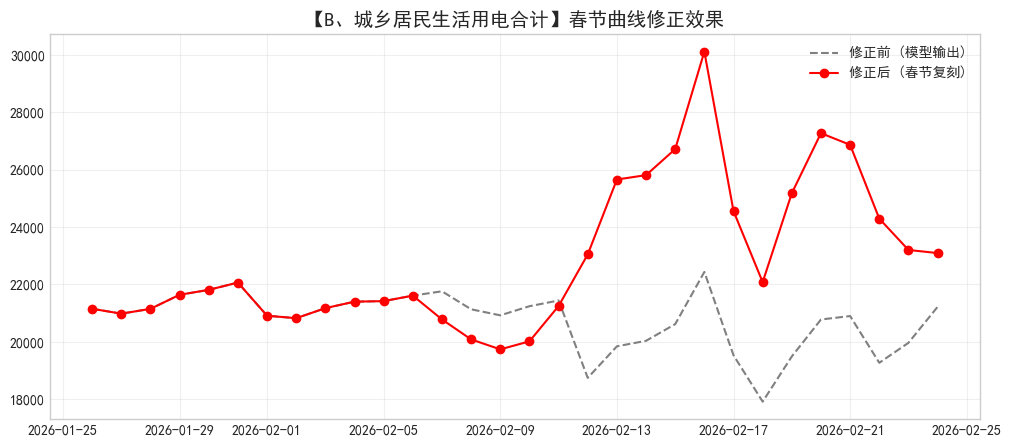

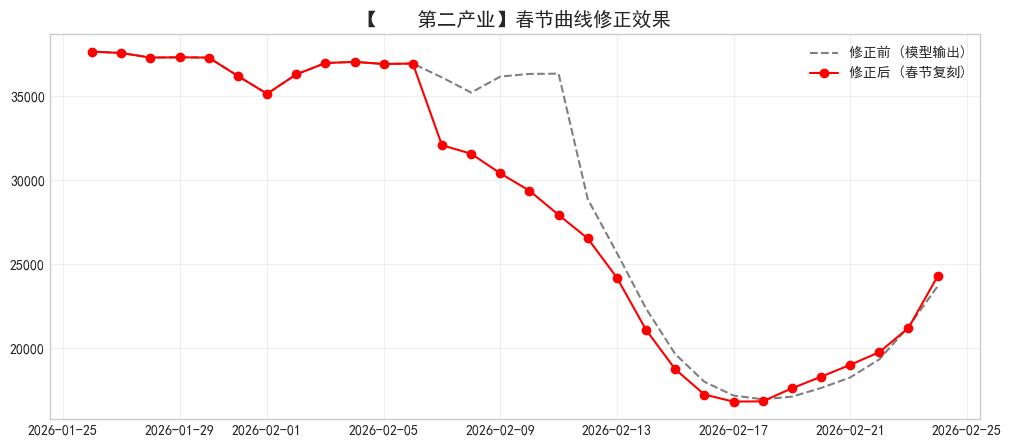

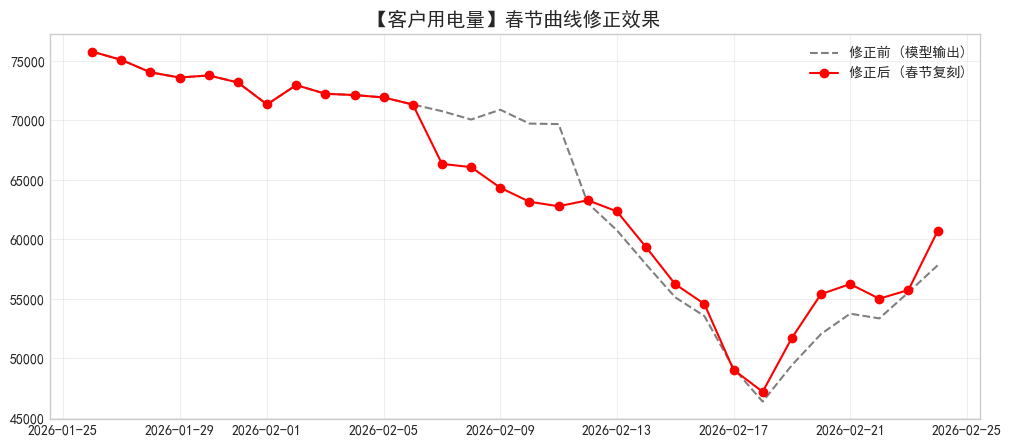

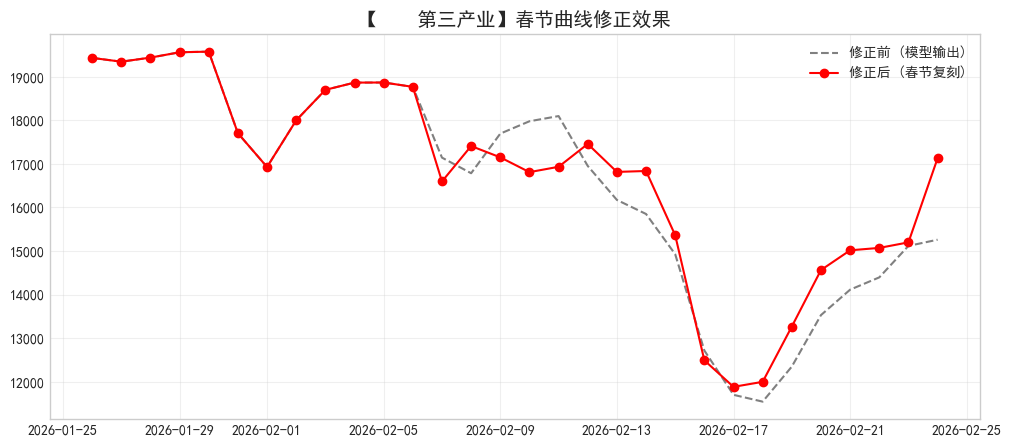

In [21]:
# %%
# ==============================================================================
# 补丁：加载模块十的预测结果 + 运行模块十一 (春节曲线强制复刻)
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. 补救措施：手动加载模块十生成的预测结果 ---
# 请确保这个路径与模块十保存的路径一致
last_step_file_path = r"E:\A智网\电量预测数据\lightgbm模型\VIP核心指标预测结果_农历修正.csv"

try:
    print(f"正在加载上一步的预测结果: {last_step_file_path}")
    vip_forecast_30d = pd.read_csv(last_step_file_path, parse_dates=['date'])
    print("✅ 成功加载 'vip_forecast_30d'，准备进行曲线复刻。")
except FileNotFoundError:
    print("❌ 错误：找不到文件。请检查模块十是否成功运行并保存了文件。")
    # 如果文件没找到，这里会停止，避免后续报错

# --- 2. 确保 df_main 存在 (如果之前运行过，应该还在内存里) ---
if 'df_main' not in locals():
    print("⚠️ 警告：'df_main' 不在内存中，正在尝试重新加载...")
    # 这里填你模块一里的路径
    panel_data_path = r"E:\A智网\电量预测数据\lightgbm模型\133个行业电量天气对齐数据_1.26.csv"
    try:
        df_main = pd.read_csv(panel_data_path, parse_dates=['date'], encoding='utf-8')
    except:
        df_main = pd.read_csv(panel_data_path, parse_dates=['date'], encoding='gbk')
    print("✅ 'df_main' 重新加载完成。")

# ==============================================================================
# 模块十一 (正式执行): 春节曲线强制复刻 (Shape Transfer)
# ==============================================================================

# --- 定义春节锚点 ---
CNY_DATES = {
    2025: pd.to_datetime('2025-01-29'), # 2025年春节
    2026: pd.to_datetime('2026-02-17')  # 2026年春节
}

def apply_shape_transfer(df_forecast, df_history, target_industries):
    print("\n" + "="*60)
    print("      启动春节曲线强制复刻 (Shape Transfer)")
    print("="*60)
    
    df_final = df_forecast.copy()
    
    # 辅助函数
    def get_days_to_cny(date_val, year):
        return (date_val - CNY_DATES[year]).days

    # 准备 2025 模板
    start_2025 = CNY_DATES[2025] - pd.DateOffset(days=40)
    end_2025 = CNY_DATES[2025] + pd.DateOffset(days=40)
    mask_2025 = (df_history['date'] >= start_2025) & (df_history['date'] <= end_2025)
    df_template = df_history[mask_2025].copy()
    df_template['days_to_cny'] = df_template['date'].apply(lambda x: get_days_to_cny(x, 2025))
    template_map = df_template.set_index(['行业名称', 'days_to_cny'])['load_MWh'].to_dict()

    for industry in target_industries:
        print(f"正在复刻曲线: {industry} ...")
        
        # 1. 计算增长率 (Growth Rate)
        # 使用春节前 15-25 天作为基准期 (避开除夕波动)
        df_final['days_to_cny'] = df_final['date'].apply(lambda x: get_days_to_cny(x, 2026))
        
        # 选取基准窗口
        base_window_mask = (df_final['行业名称'] == industry) & (df_final['days_to_cny'] >= -25) & (df_final['days_to_cny'] <= -15)
        
        if base_window_mask.sum() == 0:
            print(f"  警告：无法找到 {industry} 的基准期数据，默认增长率=1.0")
            growth_rate = 1.0
        else:
            base_load_2026 = df_final.loc[base_window_mask, 'load_MWh'].mean()
            
            hist_vals = []
            for d in range(-25, -14):
                val = template_map.get((industry, d))
                if val is not None: hist_vals.append(val)
            
            if not hist_vals:
                growth_rate = 1.0
            else:
                base_load_2025 = np.mean(hist_vals)
                growth_rate = base_load_2026 / base_load_2025
                print(f"  -> 2026预测基准: {base_load_2026:.0f}, 2025历史基准: {base_load_2025:.0f}")
                print(f"  -> 自然增长率: {growth_rate:.4f}")

        # 2. 强制复刻 (Override)
        # 修正窗口：腊月二十 (-10) 到 正月二十 (+20)
        override_window = range(-10, 21) 
        
        count_fixed = 0
        for d in override_window:
            hist_val = template_map.get((industry, d))
            if hist_val is not None:
                new_val = hist_val * growth_rate
                mask_day = (df_final['行业名称'] == industry) & (df_final['days_to_cny'] == d)
                if mask_day.any():
                    df_final.loc[mask_day, 'load_MWh'] = new_val
                    count_fixed += 1
        
        print(f"  -> 已修正 {count_fixed} 天的数据。")

    if 'days_to_cny' in df_final.columns:
        df_final = df_final.drop(columns=['days_to_cny'])
        
    return df_final

# --- 执行 ---
if 'vip_forecast_30d' in locals() and 'df_main' in locals():
    
    TARGET_SHAPE_INDUSTRIES = [
        "B、城乡居民生活用电合计",
        "    第二产业",
        "客户用电量",
        "    第三产业"
    ]
    
    vip_forecast_fixed = apply_shape_transfer(vip_forecast_30d, df_main, TARGET_SHAPE_INDUSTRIES)
    
    # 保存
    save_path_fixed = r"E:\A智网\电量预测数据\lightgbm模型\VIP核心指标预测结果_最终修正版.csv"
    vip_forecast_fixed.to_csv(save_path_fixed, index=False, encoding='utf_8_sig')
    print(f"\n✅ 最终修正版已保存: {save_path_fixed}")
    
    # 可视化
    for industry in TARGET_SHAPE_INDUSTRIES:
        if industry not in vip_forecast_fixed['行业名称'].values: continue
        
        df_old = vip_forecast_30d[vip_forecast_30d['行业名称'] == industry]
        df_new = vip_forecast_fixed[vip_forecast_fixed['行业名称'] == industry]
        
        plt.figure(figsize=(12, 5))
        plt.plot(df_old['date'], df_old['load_MWh'], linestyle='--', color='gray', label='修正前 (模型输出)')
        plt.plot(df_new['date'], df_new['load_MWh'], marker='o', color='red', label='修正后 (春节复刻)')
        plt.title(f"【{industry}】春节曲线修正效果", fontsize=14)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
else:
    print("❌ 依然缺少必要变量，请检查文件路径是否正确。")


      正在计算供暖敏感度 (单位：万千瓦时/°C)


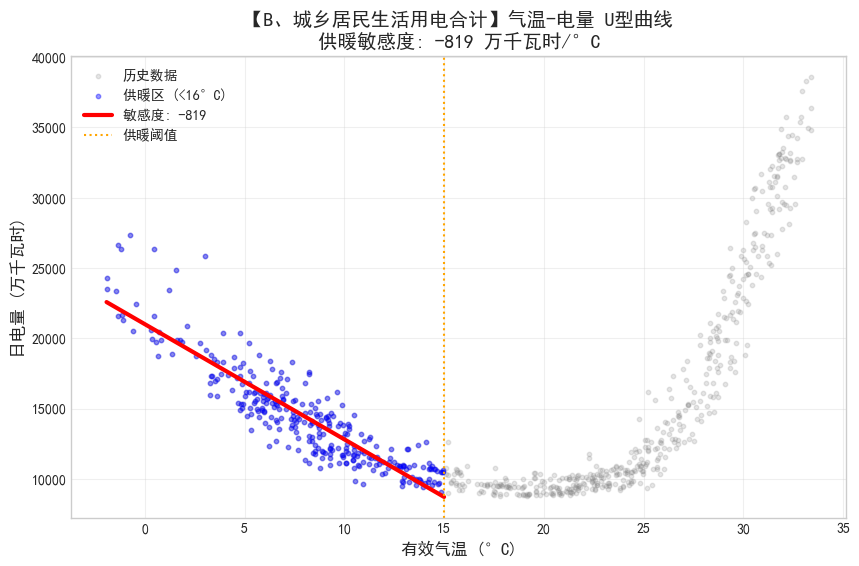

【B、城乡居民生活用电合计】
  -> 供暖敏感度: -819.23 万千瓦时/°C


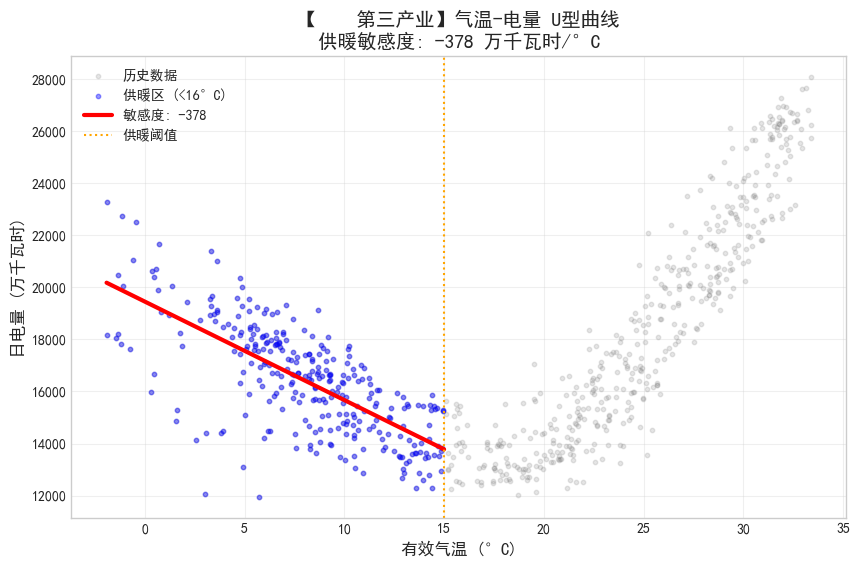

【    第三产业】
  -> 供暖敏感度: -377.91 万千瓦时/°C


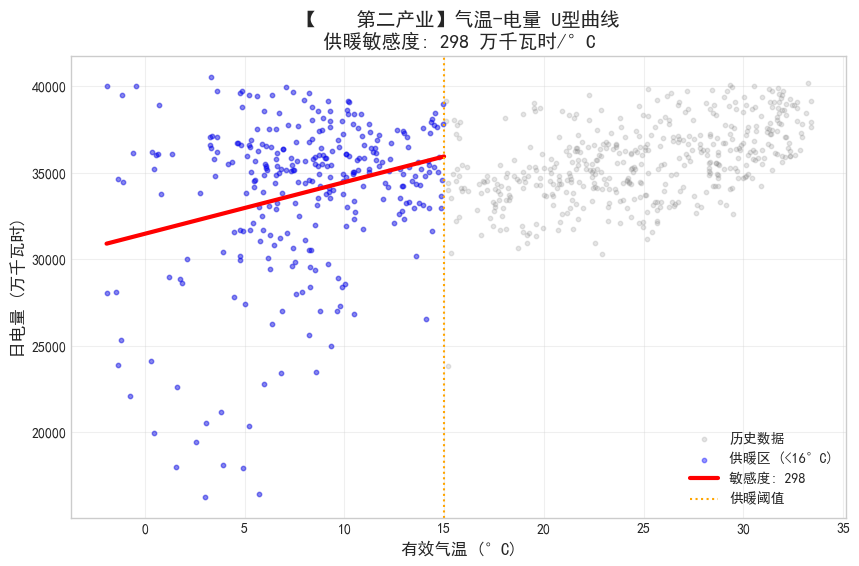

【    第二产业】
  -> 供暖敏感度: 298.05 万千瓦时/°C


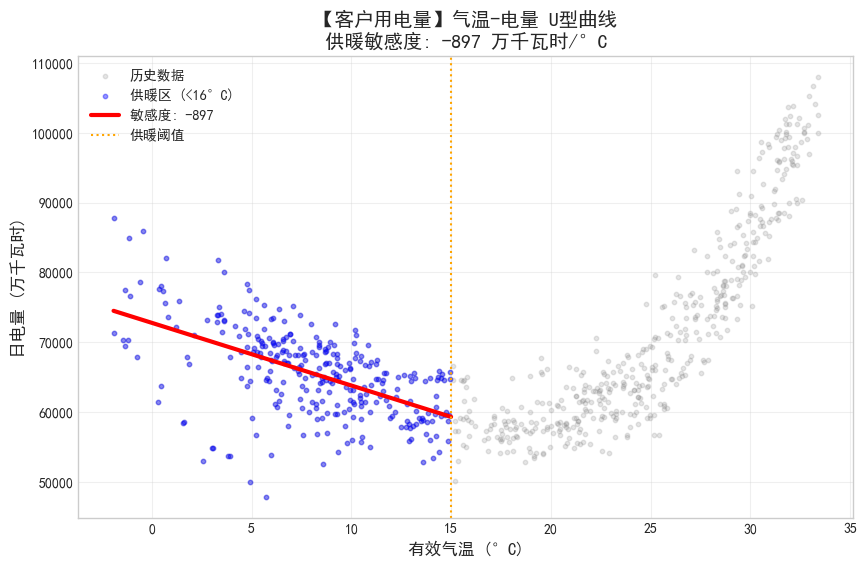

【客户用电量】
  -> 供暖敏感度: -896.65 万千瓦时/°C

请复制以下字典 (单位: 万千瓦时/°C) 到模块十二：
{'B、城乡居民生活用电合计': np.float64(-819.2293743751161), '    第三产业': np.float64(-377.91355318228636), '    第二产业': np.float64(298.0534794515126), '客户用电量': np.float64(-896.6491371046377)}


In [31]:
# %%
# ==============================================================================
# 模块十三 (最终版): U型曲线分析与供暖敏感度计算
# 数据源单位：万千瓦时
# ==============================================================================
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from chinese_calendar import is_holiday as lib_is_holiday

# --- 1. 安全日历定义 ---
MANUAL_DATE_OVERRIDES = {
    '2026-01-01': False, '2026-01-02': False, '2026-01-03': False, '2026-01-04': True,
    '2026-02-15': True,  '2026-02-16': False, '2026-02-17': False, '2026-02-18': False,
    '2026-02-19': False, '2026-02-20': False, '2026-02-21': False, '2026-02-22': False,
    '2026-02-23': False, '2026-02-24': False, '2026-02-28': True,
}

def safe_is_holiday(date_val):
    date_str = date_val.strftime('%Y-%m-%d')
    if date_str in MANUAL_DATE_OVERRIDES: return not MANUAL_DATE_OVERRIDES[date_str]
    try: return lib_is_holiday(date_val)
    except: return date_val.weekday() >= 5

def analyze_sensitivity_wan(df_load, df_weather, target_industries):
    print("\n" + "="*60)
    print("      正在计算供暖敏感度 (单位：万千瓦时/°C)")
    print("="*60)
    
    # 1. 准备数据
    weather_df = df_weather.copy().sort_index()
    # 计算有效温度 (积温)
    weather_df['temp_eff'] = (
        weather_df['temp_mean'] * 0.6 + 
        weather_df['temp_mean'].shift(1) * 0.3 + 
        weather_df['temp_mean'].shift(2) * 0.1
    )
    
    df_merged = pd.merge(df_load, weather_df[['temp_mean', 'temp_eff']], left_on='date', right_index=True, how='inner')
    df_merged['is_holiday'] = df_merged['date'].apply(safe_is_holiday).astype(int)
    
    # 筛选工作日且非0值
    # 注意：这里直接使用原始列，假设它已经是“万千瓦时”
    df_clean = df_merged[(df_merged['is_holiday'] == 0) & (df_merged['load_MWh'] > 10)].copy()
    
    sensitivity_results = {}
    
    # 设置绘图
    plt.rcParams['font.sans-serif'] = ['SimHei'] 
    plt.rcParams['axes.unicode_minus'] = False
    
    for industry in target_industries:
        data = df_clean[df_clean['行业名称'] == industry].dropna(subset=['load_MWh', 'temp_eff'])
        if len(data) < 50: continue
            
        # --- 核心逻辑：分段回归 (<16°C) ---
        HEATING_THRESHOLD = 15 
        df_heating = data[data['temp_eff'] < HEATING_THRESHOLD]
        
        if len(df_heating) > 20:
            model = LinearRegression()
            X = df_heating[['temp_eff']].values
            y = df_heating['load_MWh'].values # 直接用原始单位(万千瓦时)
            model.fit(X, y)
            coef = model.coef_[0]
            r2 = model.score(X, y)
        else:
            coef = 0
            r2 = 0
            
        sensitivity_results[industry] = coef
        
        # --- 可视化 ---
        plt.figure(figsize=(10, 6))
        
        # 画散点
        plt.scatter(data['temp_eff'], data['load_MWh'], alpha=0.2, c='gray', s=10, label='历史数据')
        plt.scatter(df_heating['temp_eff'], df_heating['load_MWh'], alpha=0.4, c='blue', s=10, label='供暖区 (<16°C)')
        
        # 画回归线
        if len(df_heating) > 20:
            x_range = np.linspace(df_heating['temp_eff'].min(), HEATING_THRESHOLD, 50).reshape(-1, 1)
            y_pred = model.predict(x_range)
            plt.plot(x_range, y_pred, color='red', linewidth=3, label=f'敏感度: {coef:.0f}')
        
        plt.title(f"【{industry}】气温-电量 U型曲线\n供暖敏感度: {coef:.0f} 万千瓦时/°C", fontsize=14)
        plt.xlabel("有效气温 (°C)", fontsize=12)
        plt.ylabel("日电量 (万千瓦时)", fontsize=12)
        plt.axvline(x=HEATING_THRESHOLD, color='orange', linestyle=':', label='供暖阈值')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
        
        print(f"【{industry}】")
        print(f"  -> 供暖敏感度: {coef:.2f} 万千瓦时/°C")

    return sensitivity_results

# --- 执行 ---
if 'df_main' in locals() and 'df_weather_full' in locals():
    VIP_INDUSTRIES = [
        "B、城乡居民生活用电合计",
        "    第三产业",
        "    第二产业",
        "客户用电量"
    ]
    
    # 计算敏感度
    REAL_SENSITIVITY_WAN = analyze_sensitivity_wan(df_main, df_weather_full, VIP_INDUSTRIES)
    
    print("\n" + "="*60)
    print("请复制以下字典 (单位: 万千瓦时/°C) 到模块十二：")
    print(REAL_SENSITIVITY_WAN)
    print("="*60)

In [32]:
# %%
# ==============================================================================
# 模块十二 (最终版): 温差修正与总量核对
# 输入数据单位：万千瓦时
# 输出报表单位：亿千瓦时
# ==============================================================================
import pandas as pd

# --- 1. 更新敏感度 (请填入上一步计算出的数值) ---
# 单位：万千瓦时/°C
# 例如：气温下降1度，居民增加 1200 万千瓦时，则填 -1200
TEMP_SENSITIVITY = {'B、城乡居民生活用电合计': np.float64(-819.2293743751161),
                    '    第三产业': np.float64(-377.91355318228636), 
                    '    第二产业': np.float64(298.0534794515126), 
                    '客户用电量': np.float64(-896.6491371046377)
                    }

def apply_temp_correction_final(df_fixed, df_weather, df_history):
    print("\n" + "="*60)
    print("      启动温差修正 (Temperature Correction)")
    print("="*60)
    
    df_res = df_fixed.copy()
    cny_2025 = pd.to_datetime('2025-01-29')
    cny_2026 = pd.to_datetime('2026-02-17')
    weather_map = df_weather['temp_mean'].to_dict()
    
    for idx, row in df_res.iterrows():
        industry = row['行业名称']
        date_2026 = row['date']
        if industry not in TEMP_SENSITIVITY: continue
        
        # 找到2025年农历同期的日期
        days_to_cny = (date_2026 - cny_2026).days
        date_2025 = cny_2025 + pd.DateOffset(days=days_to_cny)
        
        temp_2026 = weather_map.get(date_2026)
        temp_2025 = weather_map.get(date_2025)
        
        if temp_2026 is not None and temp_2025 is not None:
            temp_diff = temp_2026 - temp_2025
            sens = TEMP_SENSITIVITY.get(industry, 0)
            
            # 修正量 = 温差 * 敏感度
            # 单位：(°C) * (万千瓦时/°C) = 万千瓦时
            correction = temp_diff * sens 
            
            new_val = row['load_MWh'] + correction
            if new_val < 0: new_val = 0
            df_res.at[idx, 'load_MWh'] = new_val
            
            if idx < 1:
                print(f"[{industry}] {date_2026.date()}:")
                print(f"   温差 {temp_diff:.1f}°C (26年:{temp_2026:.1f} vs 25年:{temp_2025:.1f})")
                print(f"   修正量: {correction:.2f} 万千瓦时")

    return df_res

# --- 执行 ---
if 'vip_forecast_fixed' in locals() and 'df_weather_full' in locals():
    # 1. 执行修正
    vip_forecast_final = apply_temp_correction_final(vip_forecast_fixed, df_weather_full, df_main)
    
    # 2. 保存 (CSV里保留 万千瓦时)
    save_path_final = r"E:\A智网\电量预测数据\lightgbm模型\VIP预测_温差修正最终版.csv"
    vip_forecast_final.to_csv(save_path_final, index=False, encoding='utf_8_sig')
    
    # --- 3. 总量核对 (输出 亿千瓦时) ---
    print("\n" + "="*60)
    print("      2月总量预测报告 (单位：亿千瓦时)")
    print("="*60)
    
    # 筛选 2026年2月
    mask_feb = (vip_forecast_final['date'] >= '2026-02-01') & (vip_forecast_final['date'] <= '2026-02-28')
    df_feb = vip_forecast_final[mask_feb]
    
    # 提取各分项 (单位：万千瓦时)
    total_direct = df_feb[df_feb['行业名称'] == '客户用电量']['load_MWh'].sum()
    sec_ind = df_feb[df_feb['行业名称'] == '    第二产业']['load_MWh'].sum()
    ter_ind = df_feb[df_feb['行业名称'] == '    第三产业']['load_MWh'].sum()
    resident = df_feb[df_feb['行业名称'] == 'B、城乡居民生活用电合计']['load_MWh'].sum()
    
    # 换算单位：万千瓦时 -> 亿千瓦时
    # 1 亿 = 10,000 万
    to_yi = 1 / 10000
    
    val_total = total_direct * to_yi
    val_sec = sec_ind * to_yi
    val_ter = ter_ind * to_yi
    val_res = resident * to_yi
    val_sum = val_sec + val_ter + val_res
    
    # 估算全社会 (假设二+三+居 占 97%)
    val_sum_adjusted = val_sum / 0.97
    
    print(f"【直接预测】客户用电量: {val_total:.4f} 亿千瓦时")
    print("-" * 30)
    print(f"【分项加和】推算总量:   {val_sum_adjusted:.4f} 亿千瓦时")
    print(f"   ├─ 第二产业:       {val_sec:.4f} 亿千瓦时")
    print(f"   ├─ 第三产业:       {val_ter:.4f} 亿千瓦时")
    print(f"   └─ 城乡居民:       {val_res:.4f} 亿千瓦时")
    print("-" * 30)
    
    diff = (val_total - val_sum_adjusted) / val_total
    print(f"两者差异: {diff:.2%}")
    
    if abs(diff) > 0.05:
        print("⚠️ 建议：差异较大，推荐使用【分项加和】的结果。")
    else:
        print("✅ 校验通过。")

else:
    print("缺少必要变量。")


      启动温差修正 (Temperature Correction)
[客户用电量] 2026-01-26:
   温差 -2.1°C (26年:5.1 vs 25年:7.2)
   修正量: 1872.20 万千瓦时

      2月总量预测报告 (单位：亿千瓦时)
【直接预测】客户用电量: 148.6831 亿千瓦时
------------------------------
【分项加和】推算总量:   163.1579 亿千瓦时
   ├─ 第二产业:       63.0044 亿千瓦时
   ├─ 第三产业:       39.0463 亿千瓦时
   └─ 城乡居民:       56.2124 亿千瓦时
------------------------------
两者差异: -9.74%
⚠️ 建议：差异较大，推荐使用【分项加和】的结果。
